In [32]:
import pandas as pd

from preprocessor import Preprocessor
from visualizer import Visualizer
from semantic import SemanticAnalyser
from agent import Agent, PRICE_MAPPER
from config_local import config

# Project description

We study how large language models (LLMs) navigate Wikipedia in the Wikispeedia game, where a human player is given a start and a destination page, and their goal is to navigate from the start to the end in as few steps as possible. At each step, only outgoing links from the current page are available. We replicate this setup with LLMs and analyze how their reasoning compares to human navigation. Our analyses range from success metrics to semantic analysis of the navigation, as well as category shift patterns, so that differences between human and LLM navigation can be observed. 

With this project, we aim to answer the following question: Do LLMs show similar semantic navigation patterns to those of human players in Wikispeedia, and how do these patterns vary across prompting strategies and model sizes?

Previous research has identified a 'zooming out' phase early in navigation followed by a 'zooming in' process for human players, which we do not expect LLMs to mimic [REFERENCE].

# Explanatory analysis

At first, let's get started by exploring the Wikispeedia dataset. The dataset is composed of six files:

- *articles.tsv*: contains the list of wikipedia articles


- *categories.tsv*: contains the list of wikipedia categories


- *links.tsv*: contains the list of links between articles


- *paths_finished.tsv*: contains the list of human paths finished by the users


- *paths_unfinished.tsv*: contains the list of human paths unfinished by the users


- *shortest-path-distance-matrix.txt*: contains the shortest path distance between each pair of articles

In our project we use the following files: *categories.tsv*, *links.tsv*, *paths_finished.tsv* and *paths_unfinished.tsv*.

### High-level overview of the most common finished and unfinished paths

Here we show the five most common finished and unfinished paths based on the start page in the Wikispeedia dataset, you can see below that *Brain -> Telephone* navigation occurs over 1000 times in both the finished and unfinished files. The next navigation starting with *Brain* is only represented in 11 games, namely the *Brain -> DVD*, that is followed by *Brain -> Chestnut* with a total of 9 cases. In general, the trend in the dataset is that there tends to be one highly represented start–destination pair, while the next pairs with the same start are, in general, represented significantly less.

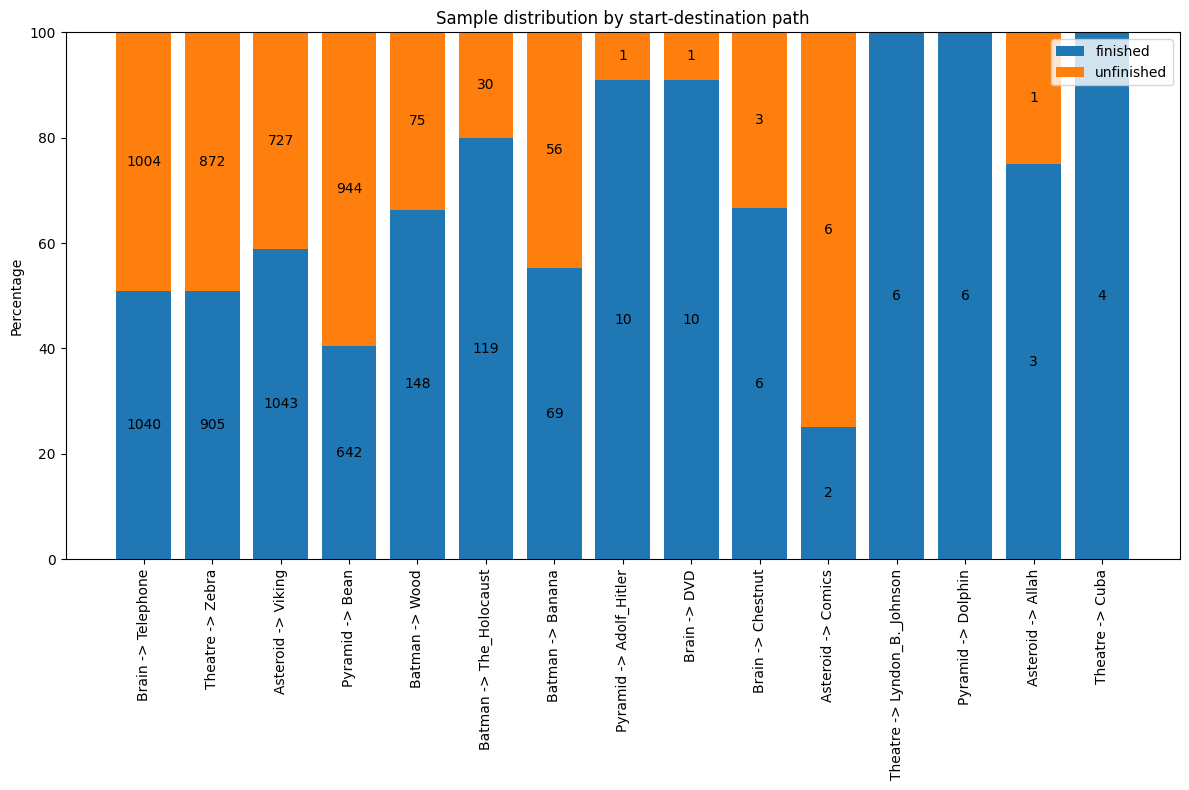

In [8]:
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)
semantic_analyser = SemanticAnalyser(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

# top k start paths with top 3 destination plotted regarding finished/unfinished source
top_k_df = preprocessor.get_top_paths_for_starts(df, 5)
visualizer.visualize_top_k(top_k_df, 'top_k_analysis.png')

### Articles, links, categories overview

At first we parse the three files via the *Preprocessor.parse_input_file* method, which dynamically reads the column names from the comment lines.

In [9]:
# parsing auxiliary files into pd.DataFrame
articles = preprocessor.parse_input_file(config.input_file_articles)
categories = preprocessor.parse_input_file(config.input_file_categories)
links = preprocessor.parse_input_file(config.input_file_links)

In [10]:
# number of articles
print(f'Total number of articles: {len(articles)}')

Total number of articles: 4604


All of the **articles** have at least one outgoing or target **link**, thus we don't have any links which are unreachable. On average, each article appears ~26 times as source and ~29 as target.

*Source links' statistics*:

In [12]:
print(links['linkSource'].value_counts().describe())

count    4587.000000
mean       26.135165
std        24.194229
min         1.000000
25%        11.000000
50%        19.000000
75%        33.000000
max       294.000000
Name: count, dtype: float64


*Target links' statistics*:

In [13]:
print(links['linkTarget'].value_counts().describe())

count    4135.000000
mean       28.992019
std        65.560574
min         1.000000
25%         4.000000
50%        10.000000
75%        29.000000
max      1551.000000
Name: count, dtype: float64


Regarding the **categories**, we have 129 unique categories. Each article can belong to multiple categories, with a maximum of three categories per article.

*Categories statistics*:

In [14]:
categories.describe()

,article,category
count,5204,5204
unique,4598,129
top,United_Kingdom,subject.Countries
freq,3,229


The distribution is uneven: a few categories account for a large share of assignments (e.g.: *subject.Countries* is the most frequent with 229 occurences), while many categories are relatively sparse as the different percentiles show.

In [21]:
categories['category'].value_counts().describe()

count    129.000000
mean      40.341085
std       34.678095
min        2.000000
25%       18.000000
50%       27.000000
75%       51.000000
max      229.000000
Name: count, dtype: float64

In [30]:
categories

,article,category
0,Áedán_mac_Gabráin,subject.History.British_History.British_Histor...
1,Áedán_mac_Gabráin,subject.People.Historical_figures
2,Åland,subject.Countries
3,Åland,subject.Geography.European_Geography.European_...
4,Édouard_Manet,subject.People.Artists
...,...,...
5199,Zirconium,subject.Science.Chemistry.Chemical_elements
5200,Zoroaster,subject.People.Religious_figures_and_leaders
5201,Zuid-Gelders,subject.Geography.European_Geography
5202,Zuid-Gelders,subject.Language_and_literature.Languages


For both the finished and unfinished paths we resolve the articles to their first category (e.g.: *subject.People.Historical_figures* becomes *Historical_figures*), if it is missing, then we assign 'Unknown'. *cat_df* contains aggregated counts per category, while *cat_df_clean* is the same table with 'Unknown' filtered out. *article_cats_finished* represents finished paths expressed as categories instead of articles, and *article_cats* includes these sequences for both finished and unfinished paths.

In [22]:
cat_df_clean, cat_df, article_cats_finished, article_cats = preprocessor.get_clean_categories_df(df, categories)

Here we investigate the ratio of the 'Unknown' categories along the finished and unfinished paths. There are 7.05% of the articles in the finished and unfinished paths for which we couldn't resolve the category.

In [31]:
# Count missing categories
mis_count = cat_df.loc[cat_df["category"] == "Unknown", "count"].sum()
mis_perc = mis_count / len(article_cats) 

# Prints
print(f"'No. of unknown categories: {mis_count}")
print(f"'Unknown' categories account for approximately {mis_perc:.2%} of all entries.")

'No. of unknown categories: 33559
'Unknown' categories account for approximately 7.05% of all entries.


Visualizing the top 15 category distributions withing our navigation paths (including both the finished and unfinished games). As the plot shows *Countries* are the most common categories (over 40000 occurences), which is expected since in the previous steps we identify *subject.Countries* as the most common category. After this *General_Biology* is the second most popular category followed by the third *Food_and_agriculture*.

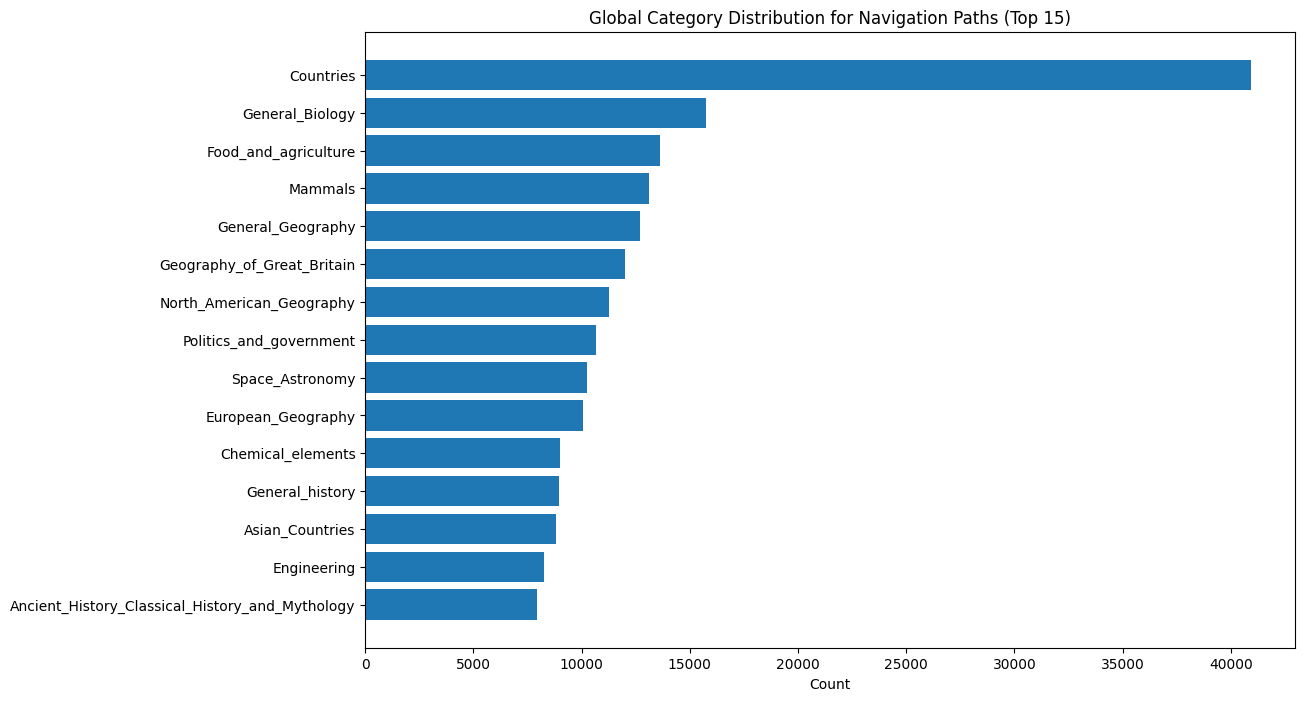

In [11]:
# Plot the 15 top categories while excluding missing categories
visualizer.visualize_category_distribution_for_paths(cat_df_clean, 'top_15_categories.png')

### Categorical Shifts

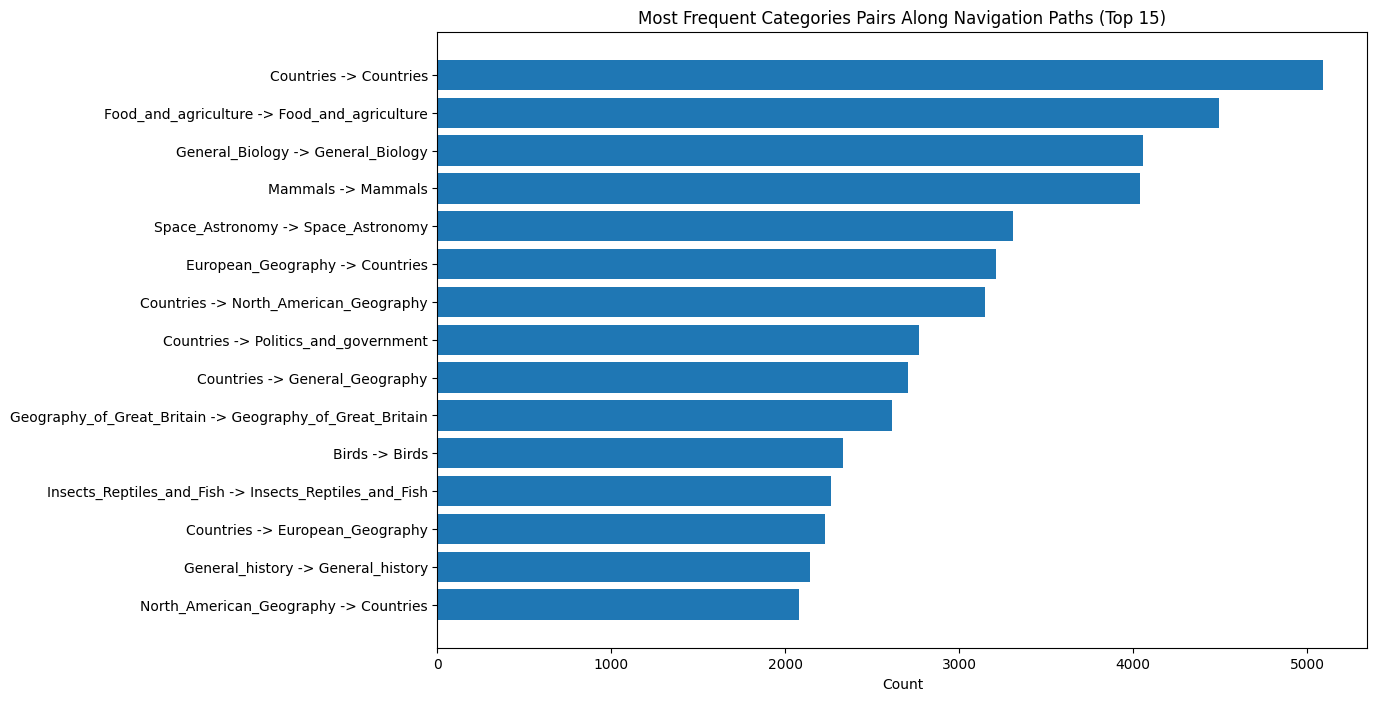

In [12]:
cat_shift_df_filter = preprocessor.get_category_shift_df(article_cats, cat_df_clean)

# Plot the most frequent categorical shifts
visualizer.visualize_top_categorical_shifts(cat_shift_df_filter, 'top_categorical_shifts.png')

The most frequent categories often occur for same categories, i.e., the user traverse articles within the same category. Below we exclude same category pairs.

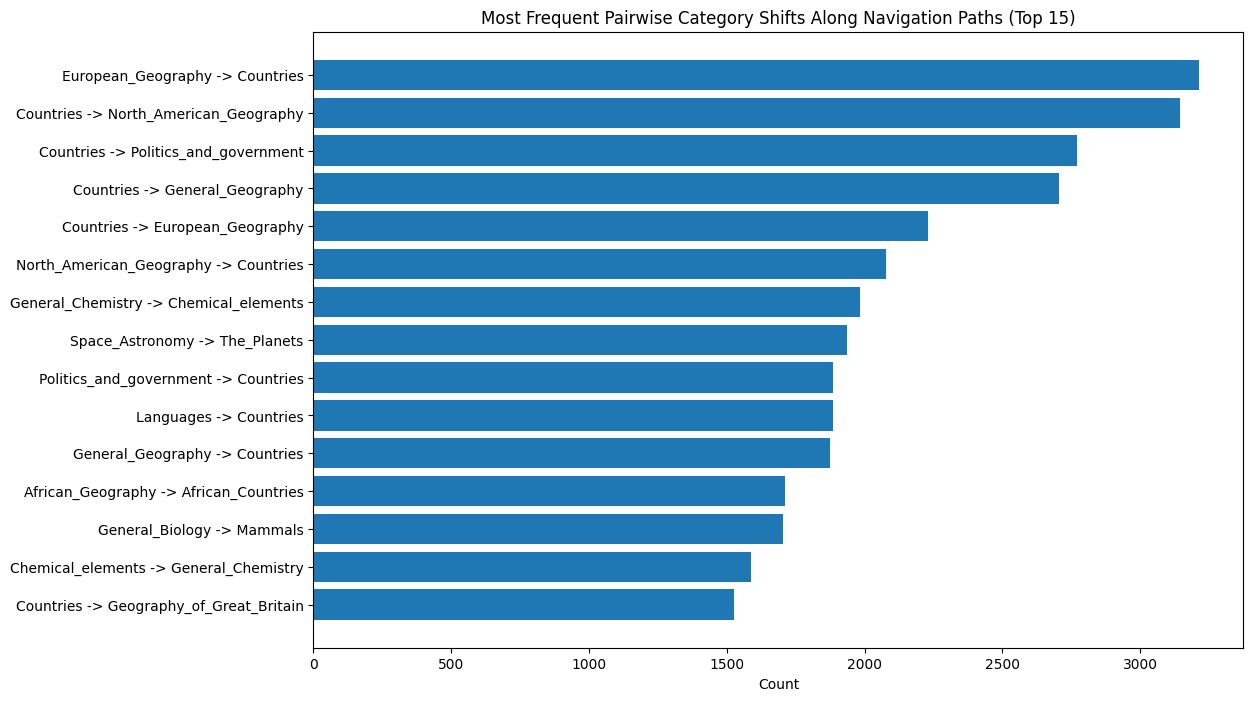

In [13]:
cat_shift_df_filter = preprocessor.get_pairwise_category_shift_df(article_cats, cat_df_clean)

# Plot the most frequent categorical shifts
visualizer.visualize_top_pairwise_categorical_shifts(cat_shift_df_filter, 'top_pairwise_categorical_shifts.png')

The 15 most frequent pairwise category shifts are categories that are related. 

Visualizing the categorical drifts along nagivation for a finished path: Interactive only inside notebook (see cat_shift.png for static image)

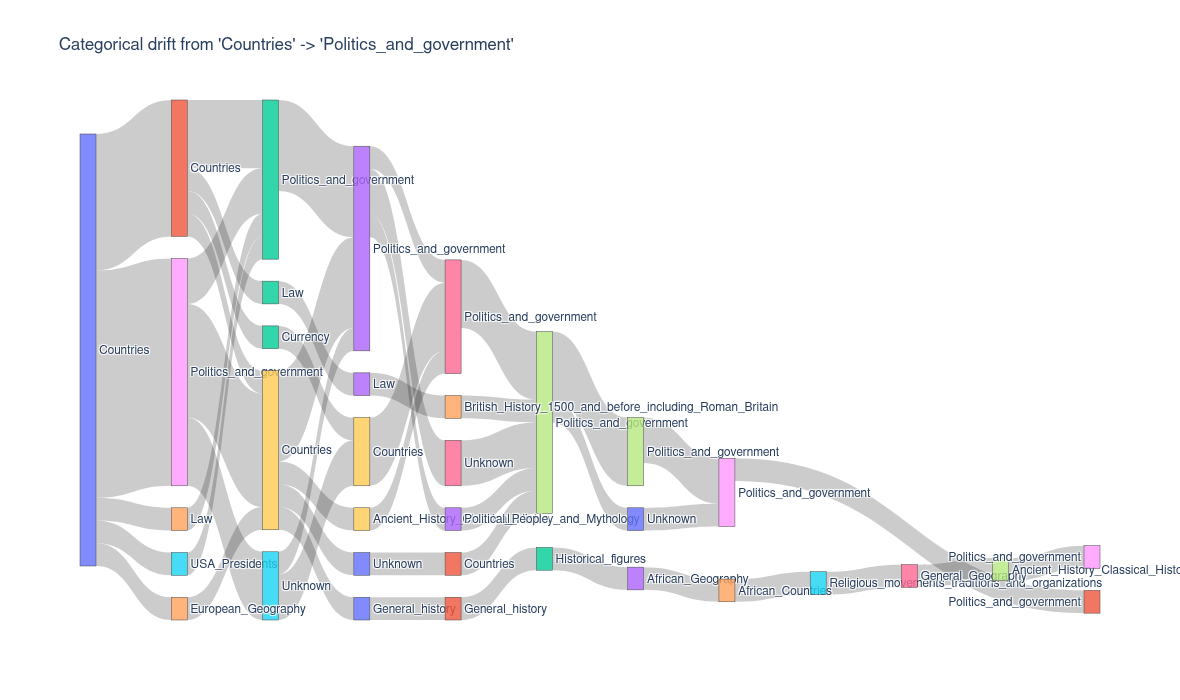

In [14]:
# Define start and end category
start_cat, end_cat = "Countries", "Politics_and_government"
cat_shift_df_pairs = preprocessor.get_category_shifts_df_pairs(article_cats_finished, start_cat, end_cat)

# Sankey diagram
# Reference: https://plotly.com/python/sankey-diagram/
filename = 'cat_shift_plot.png'
visualizer.visualize_sankey_plot(cat_shift_df_pairs, filename, start_cat, end_cat)

# Display the saved sankey plot
from IPython.display import Image, display
display(Image(filename=visualizer.gen_output_path(filename)))

<h3>Paths</h3>

We have access to many paths; there are 51,318 finished paths in total and 24,875 unfinished paths.

In [15]:
#number of finished vs unfinished paths
print('num of finished paths:', len(df[df['target'].isnull()]))
print('num of unfinished paths:', len(df[df['target'].notnull()]))

num of finished paths: 51318
num of unfinished paths: 24875


some paths have '<' in them, indicating backtracking by human players

we can simply resolve them by skipping back to the previous article and continuing from there

In [16]:
df[df['path'].astype(str).str.contains('<')].head(10)['path']

10    14th_century;Time;Science;Nature;Weather;Sunli...
13    14th_century;Renaissance;Empiricism;Nature;Wea...
14    14th_century;Renaissance;Leonardo_da_Vinci;Wat...
16    14th_century;Europe;Republic_of_Ireland;<;<;Eu...
19    14th_century;Time;Physics;<;Day;Sun;Sunlight;U...
36    14th_century;England;London;Spanish_Armada;Eng...
41    14th_century;Europe;<;England;<;Christianity;A...
42    2004_Atlantic_hurricane_season;U.S._state;Unit...
47    2004_Atlantic_hurricane_season;El_Niño-Souther...
49    2004_Atlantic_hurricane_season;Atlantic_Ocean;...
Name: path, dtype: object

In [17]:
resolved_df = preprocessor.resolve_all_parsed_paths(df.copy())

In [18]:
#check if all '<' are resolved
print('num of paths with < after resolution:', resolved_df['path'].astype(str).str.contains('<').sum())

num of paths with < after resolution: 0


Some finished paths have a length of 1, indicating that the player is already at the target article, so we can simply remove those paths


In [19]:
print('num of finished paths with length 1 before removal:', len(resolved_df.loc[(resolved_df['source'] == 'finished') & (resolved_df['num_hops'] == 1)]))

num of finished paths with length 1 before removal: 11


In [20]:
# remove finished paths with length 1
filtered_finished_paths = resolved_df.drop(resolved_df.loc[(resolved_df['source'] == 'finished') & (resolved_df['num_hops'] == 1)].index)

<h3>Difficulties</h3>

Lets get the distribution of difficulties for finished and unfinished paths:

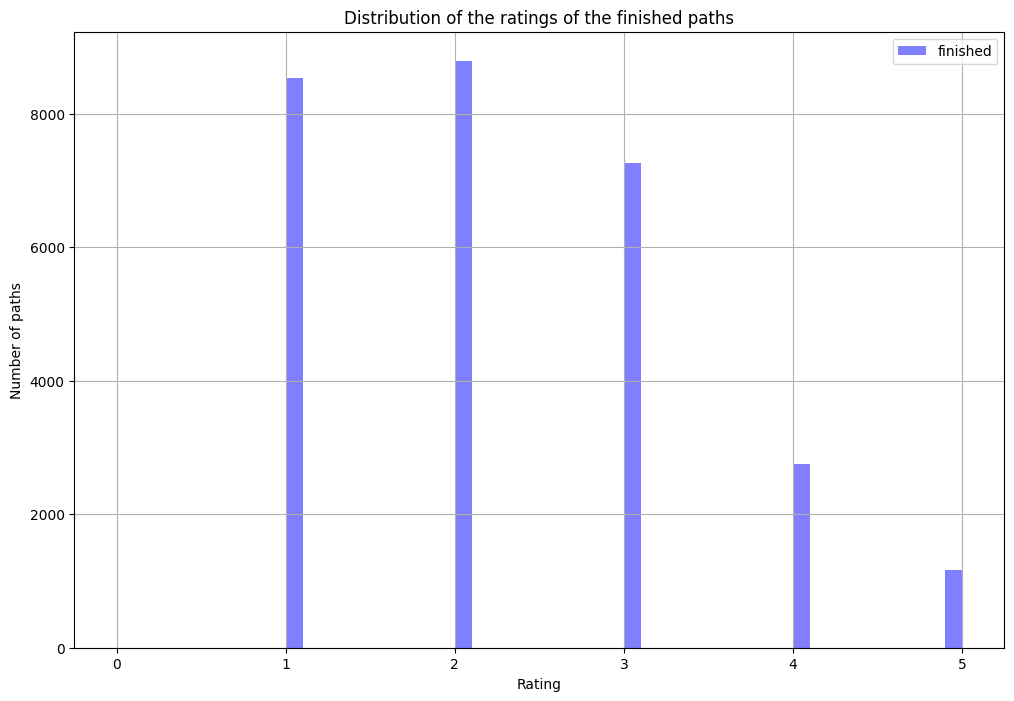

In [21]:
#get the distribution of difficulties for finished and unfinished paths
visualizer.visualize_ratings_distribution(filtered_finished_paths, 'ratings_distribution.png')

The rating distribution is imbalanced, so before conducting our further experiments, we can potentially stratify the dataset based on rating.

<h3>Semantics</h3>

We can visualize the semantic space of all articles using their embeddings obtained by sentence transformers:   

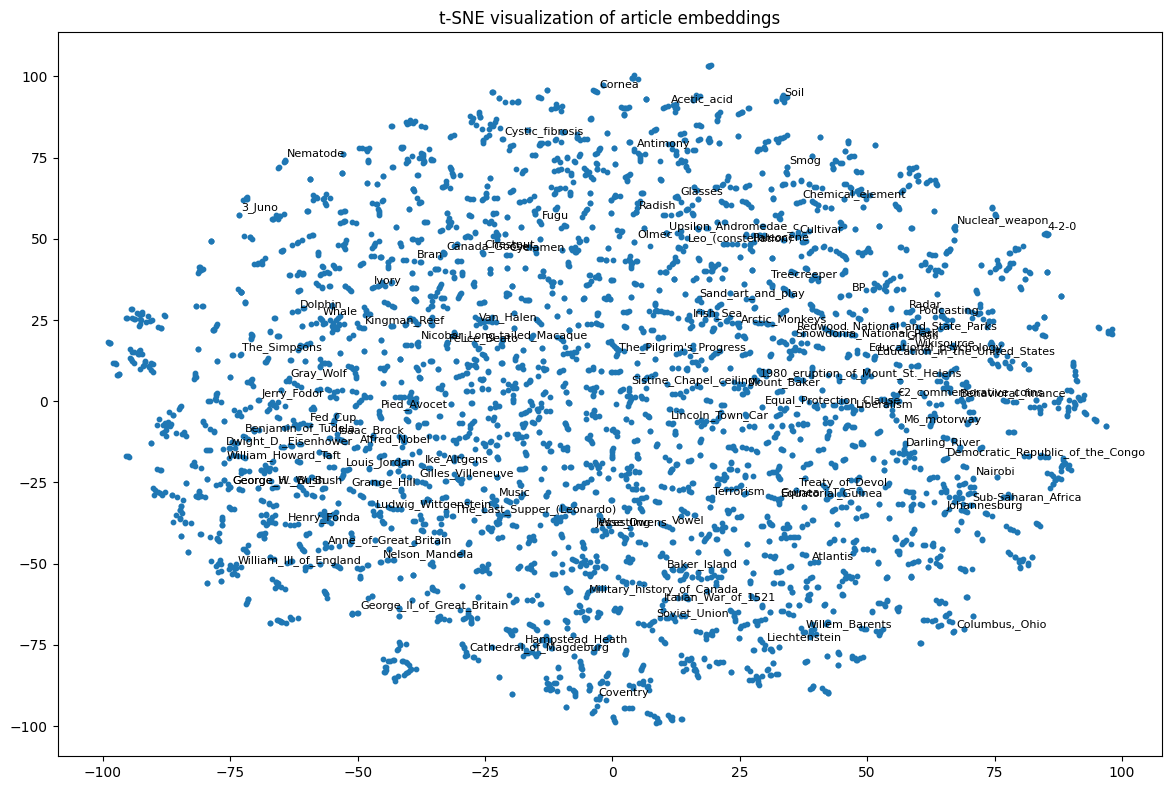

In [24]:
#semantic distribution of articles
visualizer.visualize_semantic_space(
    filename="semantic_space.png",
    metadata=articles,
    emb_path="results/article_emb/embeddings.pt"
)

Below is the hop distribution for paths from Brain to Telephone, only considering finished paths:

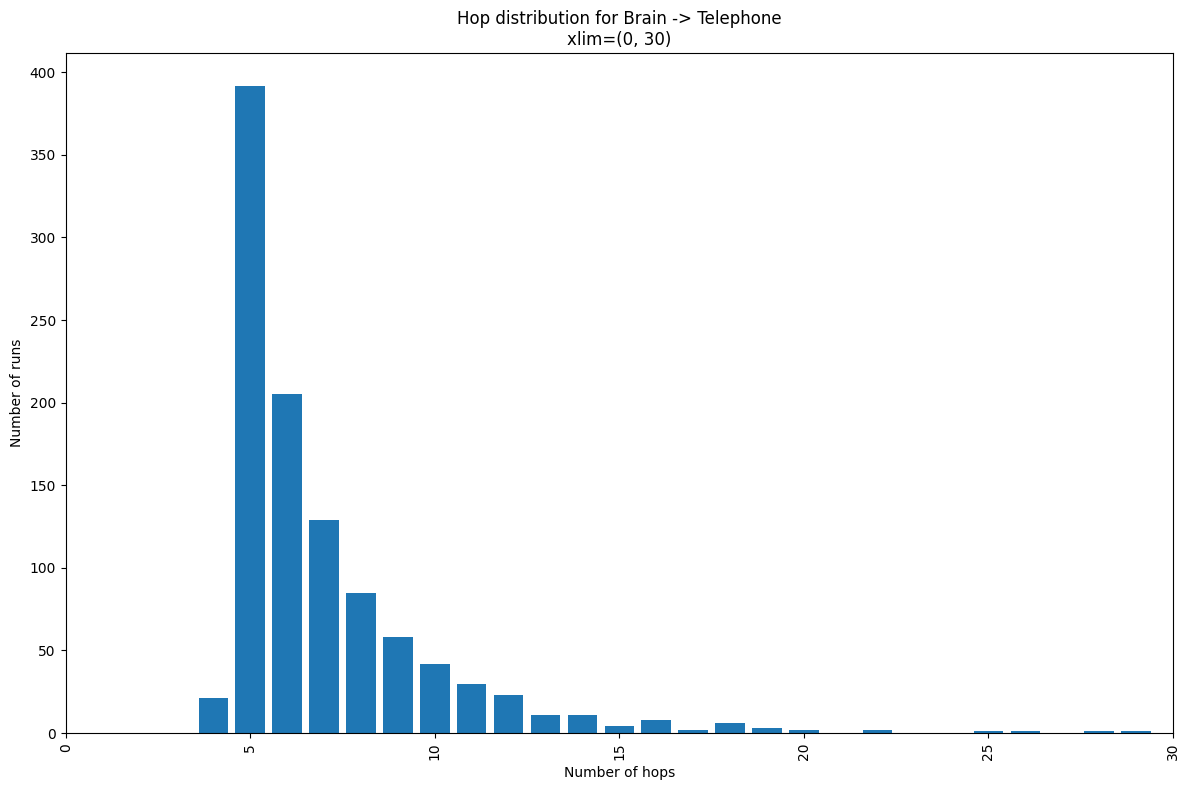

In [26]:
# hop distribtutions for Brain -> Telephone path, only considering finished paths
start, destination = 'Brain', 'Telephone'
hop_distribution = preprocessor.get_hop_distribution(df, start, destination)
visualizer.visualize_hop_distribution(
    hop_distribution,
    'brain_to_telephone_hop_distribution.png',
    (0, 30),
    start,
    destination
)

We can see that most paths from Brain to Telephone have around 5 hops.

<h2>Information Gain Analysis</h2>

We can analyze the information gain along the navigation paths from start to destination. The information gain is calculated based on the cosine similarity between current article and target article embeddings obtained from a sentence transformer model. Below is an example of analyzing the information gain for paths from "Brain" to "Telephone".

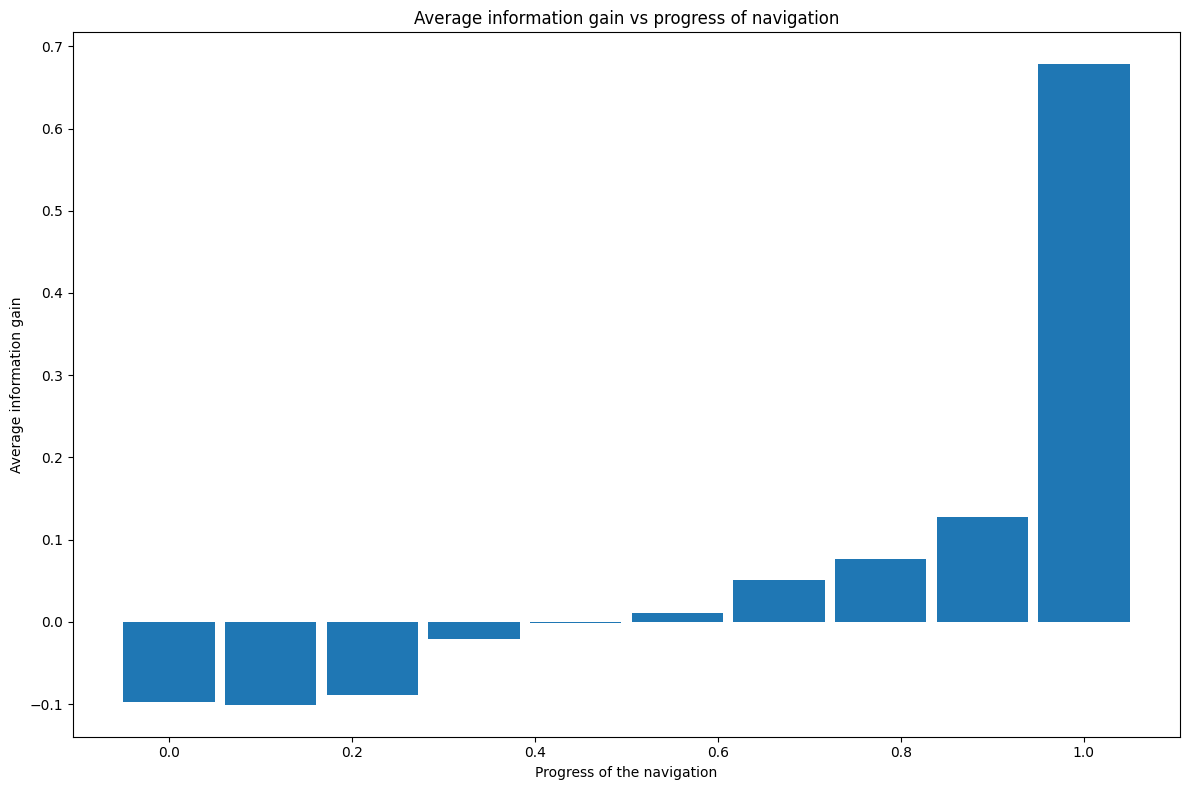

In [27]:
# generate embeddings for all the article titles, also save_dir can be overruled in config
semantic_analyser.generate_embeddings(articles)

# get all of the paths for start and destination
paths = preprocessor.get_parsed_paths(df, start, destination)

# calculate information gain by cosine similarity
avg_information_gain = semantic_analyser.get_avg_information_gain(paths)

# visualize information gain against the navigation progress
visualizer.visualize_information_gain(avg_information_gain, 'avg_information_gain_vs_progress.png')

Here we have an example test on path generation using a LLM agent. The agent uses the Tree of Thoughts (ToT) approach to generate navigation paths from start to destination.

<h1>Comparison of Human players vs LLMs</h1>


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# initializing high level instances, with config
from preprocessor import Preprocessor
from config_local import config
import pandas as pd
from visualizer import Visualizer
from semantic import SemanticAnalyser

# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)
semantic_analyser = SemanticAnalyser(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

#### Load LLM genereated paths

In [3]:
# Load  genereated paths by the LLMs
#llm_df = pd.read_csv("results/llm_paths_oss_20b.csv")
llm_df = pd.read_csv("results/llm_paths_oss_120b.csv")

### Data Preprocessing

#### Clean LLM generated paths

In [5]:
# Clean LLMs paths (None, NaNs, loops, hallucationed articles)
blind_paths = preprocessor.clean_llm_paths(llm_df, "blind_paths")                        # One-shot 
link_aware_paths = preprocessor.clean_llm_paths(llm_df, "link_aware_paths")              # CoT
external_info_paths = preprocessor.clean_llm_paths(llm_df, "external_info_paths")        # CoT with knowledge graph information
tot_paths = preprocessor.clean_llm_paths(llm_df, "tot_paths")                            # ToT

# Print summary and sample
print("blind_paths:")
print(f"blind_paths: {len(blind_paths)} paths cleaned")
print(f"Sample: {blind_paths['path_list'].iloc[42]}")
print(f"Total NaNs: {blind_paths.isna().sum().sum()}")
print("--------------------")

print("link_aware_paths:")
print(f"link_aware_paths: {len(link_aware_paths)} paths cleaned")
print(f"Sample: {link_aware_paths['path_list'].iloc[42]}")
print(f"Total NaNs: {link_aware_paths.isna().sum().sum()}")
print("--------------------")

print("external_info_paths:")
print(f"external_info_paths: {len(external_info_paths)} paths cleaned")
print(f"Sample: {external_info_paths['path_list'].iloc[42]}")
print(f"Total NaNs: {external_info_paths.isna().sum().sum()}")
print("--------------------")

print("tot_paths:")
print(f"tot_paths: {len(tot_paths)} paths cleaned")
print(f"Sample: {tot_paths['path_list'].iloc[42]}")
print(f"Total NaNs: {tot_paths.isna().sum().sum()}")
print("--------------------")

blind_paths:
blind_paths: 233 paths cleaned
Sample: ['Asteroid', 'Space', 'NASA', 'Viking program', 'Viking']
Total NaNs: 0
--------------------
link_aware_paths:
link_aware_paths: 189 paths cleaned
Sample: ['Archbishop_of_Canterbury', 'Roman_Catholic_Church', 'Asia', 'Vietnam']
Total NaNs: 0
--------------------
external_info_paths:
external_info_paths: 197 paths cleaned
Sample: ['Batman', 'Crime', 'Religion', 'Bible']
Total NaNs: 0
--------------------
tot_paths:
tot_paths: 199 paths cleaned
Sample: ['Batman', 'Crime', 'Religion', 'Bible']
Total NaNs: 0
--------------------


#### Clean Human Player Paths

In [6]:
#categories = preprocessor.parse_input_file(config.input_file_categories)

# Only finished paths (perhaps a better idea for the salluviate plot?)
df_finished = df[df["source"] == "finished"].copy()

# Extract the category (final element) and create the article -> category mappings
article_to_cat = (
    categories.assign(cat_short=categories["category"].str.split(".").str[-1])
    .groupby("article")["cat_short"]
    .apply(list)
    .to_dict()
)

# Map all articles in the navigation paths to its first category (mapping missing articles to 'unknown' as there is no category list available)
article_cats = [article_to_cat.get(p, ["Unknown"])[0] for path in df["path"] for p in path.split(";")]
# For finished path (not flattened): used for the  alluviate plot
article_cats_finished = [[article_to_cat.get(p, ["Unknown"])[0] for p in path.split(";")]for path in df_finished["path"]]

### Categorical Shifts Comparison

#### Compute the categorical shifts per navigatin path and step for LLMs

In [8]:
# Adaspeedia llm paths results (test)
#shifts_path_llms, shifts_step_llms = preprocessor.get_shifts_per_path(llm_article_cats_finished)

# Blind paths: One-shot
blind_article_cats = blind_paths["path_list"].tolist()
blind_paths_shift, blind_steps_shift = preprocessor.get_shifts_per_path(blind_article_cats)

# Link aware paths: CoT
link_aware_article_cats = link_aware_paths["path_list"].tolist()
link_aware_paths_shift, link_aware_steps_shift = preprocessor.get_shifts_per_path(link_aware_article_cats)

# External info paths:  CoT with knowledge graph information
external_info_article_cats = external_info_paths["path_list"].tolist()
external_info_paths_shift, external_info_steps_shift = preprocessor.get_shifts_per_path(external_info_article_cats)

# ToT paths: ToT with a maximum depth of 14 and for each layer
tot_article_cats = tot_paths["path_list"].tolist()
tot_paths_shift, tot_steps_shift = preprocessor.get_shifts_per_path(tot_article_cats)

#### Compute the categorical shifts per navigatin path and step for Humans

In [7]:
# Humans: Categorical shifts per navigatin path
shifts_path_humans, shifts_step_humans = preprocessor.get_shifts_per_path(article_cats_finished)

#### Compare the average categorial shifts along the entire navigation paths

In [10]:
# Compute average categorical shifts per navigation path for Humans
average_shift_humans = preprocessor.get_average_categorical_shifts_path(article_cats_finished)
print(f"Average categorical shift along entire navigation paths (Humans): {average_shift_humans:.3f}")

# Compute average categorical shifts per navigation path for LLMs:
# Blind paths: One-shot
average_shift_blind = preprocessor.get_average_categorical_shifts_path(blind_paths["path_list"].tolist())
print(f"Average categorical shift along entire navigation paths (blind_paths): {average_shift_blind:.3f}")

# Link aware paths: CoT
average_shift_link_aware = preprocessor.get_average_categorical_shifts_path(link_aware_paths["path_list"].tolist())
print(f"Average categorical shift along entire navigation paths (link_aware_paths): {average_shift_link_aware:.3f}")

# External info paths:  CoT with knowledge graph information
average_shift_external_info = preprocessor.get_average_categorical_shifts_path(external_info_paths["path_list"].tolist())
print(f"Average categorical shift along entire navigation paths (external_info_paths): {average_shift_external_info:.3f}")

# ToT paths: ToT with a maximum depth of 14 and for each layer
average_shift_tot = preprocessor.get_average_categorical_shifts_path(tot_paths["path_list"].tolist())
print(f"Average categorical shift along entire navigation paths (tot_paths): {average_shift_tot:.3f}")

Average categorical shift along entire navigation paths (Humans): 4.577
Average categorical shift along entire navigation paths (blind_paths): 4.103
Average categorical shift along entire navigation paths (link_aware_paths): 4.101
Average categorical shift along entire navigation paths (external_info_paths): 4.193
Average categorical shift along entire navigation paths (tot_paths): 4.146


#### Compare step-wise mean categorical shits along the entire navigation paths (normalized as progress [0,1])

In [91]:
# Compute stepwise shift vectors for each player type
shifts_step_humans       = preprocessor.compute_stepwise_shift_vectors(article_cats_finished)
blind_steps_shift        = preprocessor.compute_stepwise_shift_vectors(blind_paths["path_list"].tolist())
link_aware_steps_shift   = preprocessor.compute_stepwise_shift_vectors(link_aware_paths["path_list"].tolist())
external_info_steps_shift= preprocessor.compute_stepwise_shift_vectors(external_info_paths["path_list"].tolist())
tot_steps_shift          = preprocessor.compute_stepwise_shift_vectors(tot_paths["path_list"].tolist())

cat_shift_dict = {
    "Humans": shifts_step_humans,
    "One-shot": blind_steps_shift,
    "CoT": link_aware_steps_shift,
    "CoT(KB)": external_info_steps_shift,
    "ToT": tot_steps_shift
}


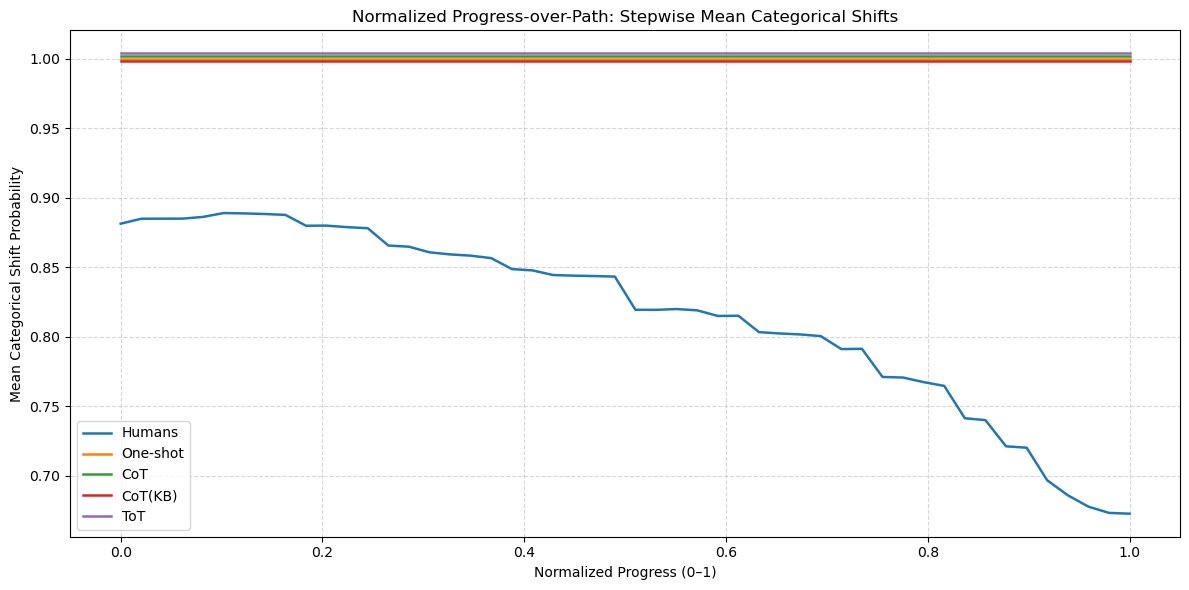

In [92]:
# Compute stepwise mean categorical shifts
mean_shifts_normal = preprocessor.compute_stepwise_mean_shifts(cat_shift_dict)

# Plot Step-wise mean categorical shifts (Paths normalized [0,1])
visualizer.visualize_categorical_shifts_mean_stepwise(mean_shifts_normal)

### Semantical Similarity Comparison

Load embeddings and metadata

In [86]:
embeddings = torch.load("results/article_emb/embeddings.pt", weights_only=True).numpy()
metadata = pd.read_csv("results/article_emb/metadata.csv")
article_to_idx = {row['article']: i for i, row in metadata.iterrows()}

Get the mean similarity, progress axis, and stepwise_similarity

In [100]:
sem_sim_dict = {
    "Humans": article_cats_finished,
    "One-shot": blind_paths["path_list"].tolist(),
    "CoT": link_aware_paths["path_list"].tolist(),
    "CoT(KB)": external_info_paths["path_list"].tolist(),
    "ToT": tot_paths["path_list"].tolist()
}

mean_similarity, progress_axis, stepwise_similarity = preprocessor.compute_stepwise_mean_similarity(
    sem_sim_dict,
    article_to_idx,
    embeddings
)

#### Plot temporal normalized progress plot showing the step-wise mean similarity

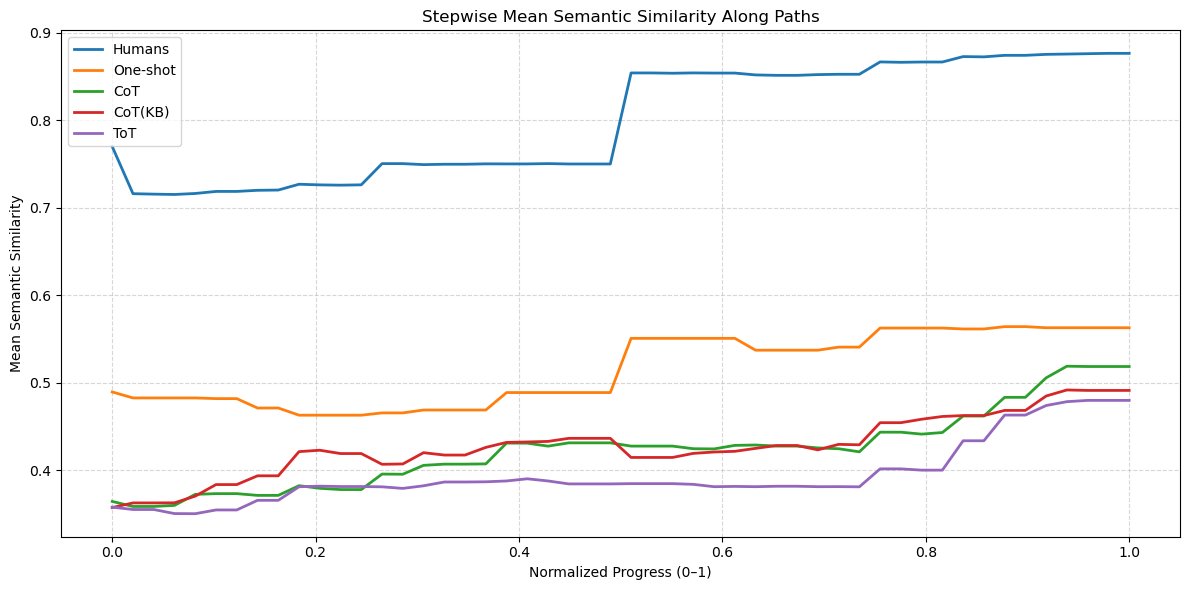

In [108]:
# Chart showing the step-weise mean similarity over normalized progress [0,1]
visualizer.visualize_stepwise_mean_similarity(mean_similarity, progress_axis)

#### Step-wise mean similarity distribution

In [110]:
stepwise_similarity_flat = preprocessor.compute_flat_stepwise_similarity(
    groups=sem_sim_dict,
    article_to_idx=article_to_idx,
    embeddings=embeddings
)

Violin plot for the step-wise similarity distribution

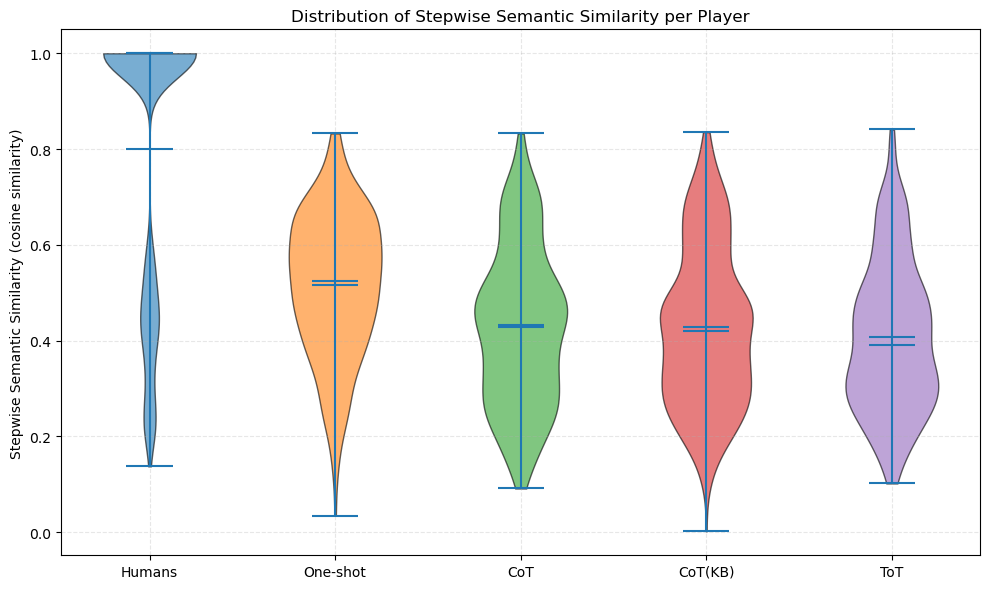

In [112]:
visualizer.plot_stepwise_similarity_violin(stepwise_similarity_flat)

### Plot the path length distributions 

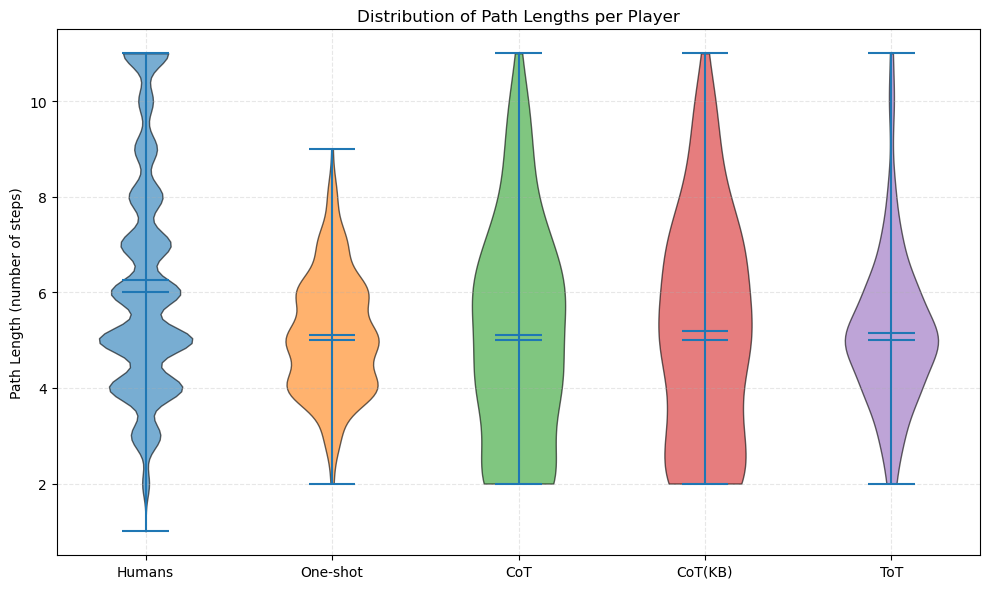

In [119]:
visualizer.plot_path_length_distribution(groups=sem_sim_dict)

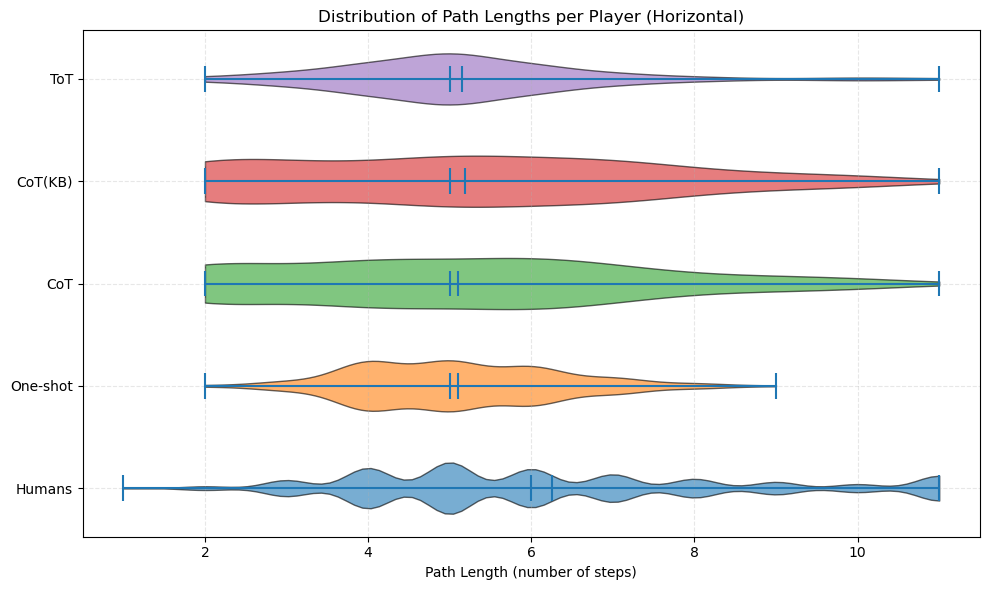

In [121]:
visualizer.plot_path_length_distribution_horizontal(groups=sem_sim_dict)

<h1>Comparison of Human players vs LLMs</h1>

In [28]:
# parsing links.tsv into pd.DataFrame
links_df = preprocessor.parse_input_file('data/wikispeedia_paths-and-graph/links.tsv')

# create link mapping from links_df
link_mappings = preprocessor.get_link_mappings(links_df)

# create high level agent instance
agent = Agent(config, link_mappings)

# llm_tot_path = agent.navigate_tot(start, destination, with_memory=False)
# f'Path generated by LLM using ToT: {llm_tot_path}'

In [29]:
# llm_link_ware_path = agent.navigate_link_aware(start, destination)
# f'Path generated by LLM using link-aware approach: {llm_link_ware_path}'

In [30]:
# llm_blind_path = agent.navigate_blind(start, destination)
# f'Path generated by LLM using blind approach: {llm_blind_path}'

In [31]:
# llm_external_path = agent.navigate_with_external_info(start, destination)
# f'Path generated by LLM using external info approach: {llm_external_path}'

In [32]:
resolved_df.head()


,hashedIpAddress,timestamp,durationInSec,path,rating,source,target,type,start,end,num_hops,destination
0,6a3701d319fc3754,1297740409,166,"[14th_century, 15th_century, 16th_century, Pac...",NaN,finished,NaN,NaN,14th_century,African_slave_trade,9,African_slave_trade
1,3824310e536af032,1344753412,88,"[14th_century, Europe, Africa, Atlantic_slave_...",3.0,finished,NaN,NaN,14th_century,African_slave_trade,5,African_slave_trade
2,415612e93584d30e,1349298640,138,"[14th_century, Niger, Nigeria, British_Empire,...",NaN,finished,NaN,NaN,14th_century,African_slave_trade,8,African_slave_trade
3,64dd5cd342e3780c,1265613925,37,"[14th_century, Renaissance, Ancient_Greece, Gr...",NaN,finished,NaN,NaN,14th_century,Greece,4,Greece
4,015245d773376aab,1366730828,175,"[14th_century, Italy, Roman_Catholic_Church, H...",3.0,finished,NaN,NaN,14th_century,John_F._Kennedy,7,John_F._Kennedy


In [33]:
df_for_experiment = preprocessor.get_pairs_for_experiment(resolved_df,num_pairs=20)             
#30 top played games
df_for_experiment

,start,destination,success_count,sample_count,success_rate,difficulty,replicate_idx,id
0,Brain,Telephone,1040,2044,0.508806,Medium,0,Brain_Telephone_0
1,Theatre,Zebra,905,1777,0.509285,Medium,0,Theatre_Zebra_0
2,Asteroid,Viking,1043,1770,0.589266,Medium,0,Asteroid_Viking_0
3,Batman,Wood,148,223,0.663677,Medium,0,Batman_Wood_0
4,Beer,Sun,99,142,0.697183,Medium,0,Beer_Sun_0
...,...,...,...,...,...,...,...,...
115,Napoleonic_Wars,Superman,5,14,0.357143,Hard,2,Napoleonic_Wars_Superman_2
116,Batman,Wikisource,4,13,0.307692,Hard,2,Batman_Wikisource_2
117,Christianity,Coconut_crab,4,13,0.307692,Hard,2,Christianity_Coconut_crab_2
118,David_Beckham,Frog,5,13,0.384615,Hard,2,David_Beckham_Frog_2


In [34]:
agent.generate_llm_paths(df_for_experiment)

Found 46 already completed pairs.
So far input price: 0.05$, output price: 0.35$


  0%|                                                                                                                                                               | 0/120 [00:00<?, ?it/s]

Skipping Brain_Telephone_0, since it has already been generated.
Skipping Theatre_Zebra_0, since it has already been generated.
Skipping Asteroid_Viking_0, since it has already been generated.
Skipping Batman_Wood_0, since it has already been generated.
Skipping Beer_Sun_0, since it has already been generated.
Skipping Batman_Banana_0, since it has already been generated.
Skipping Cat_Computer_0, since it has already been generated.
Skipping Cat_Microsoft_0, since it has already been generated.
Skipping Dog_Telephone_0, since it has already been generated.
Skipping Dog_Venus_0, since it has already been generated.
Skipping Aluminium_chloride_Parrot_0, since it has already been generated.
Skipping Batman_Bible_0, since it has already been generated.
Skipping England_God_0, since it has already been generated.
Skipping Art_Mango_0, since it has already been generated.
Skipping 14th_century_Rainbow_0, since it has already been generated.
Skipping Electricity_God_0, since it has already be

 39%|██████████████████████████████████████████████████████████▊                                                                                           | 47/120 [07:05<11:01,  9.06s/it]

Succeeded on attempt 1.
total input: 1013736 tokens so far
total output: 792399 tokens so far
So far input price: 0.05$, output price: 0.36$
elapsed time: 425.82 seconds
start: Cat, destination: Microsoft (replicate: 1)
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Attempt 1 failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded.', 'type': 'rate_limit_exceeded_error'}, 'message': 'Rate limit exceeded.', 'status_code': 429}.

Retrying in 30s (next attempt 2/3)
Attempt 2 starting.
Succeeded on attempt 2.
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Attempt 1 failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded.', 'type': 'rate_limit_exceeded_error'}, 'message': 'Rate limit exceeded.', 'status_code': 429}.

Retrying in 30s (next attempt 2/3)
Attempt 2 starting.
Succeeded on attempt 2.
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 

 40%|████████████████████████████████████████████████████████████                                                                                          | 48/120 [24:13<46:56, 39.12s/it]

Succeeded on attempt 1.
total input: 1059864 tokens so far
total output: 824532 tokens so far
So far input price: 0.05$, output price: 0.37$
elapsed time: 1027.94 seconds
start: Dog, destination: Telephone (replicate: 1)
Attempt 1 starting.
Succeeded on attempt 1.
Attempt 1 starting.
Attempt 1 failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded.', 'type': 'rate_limit_exceeded_error'}, 'message': 'Rate limit exceeded.', 'status_code': 429}.

Retrying in 30s (next attempt 2/3)


 40%|████████████████████████████████████████████████████████████                                                                                          | 48/120 [24:24<36:36, 30.51s/it]


KeyboardInterrupt: 